In [1]:
# Cell 1: Imports
import os
import numpy as np
from tqdm import tqdm
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.cross_decomposition import PLSRegression

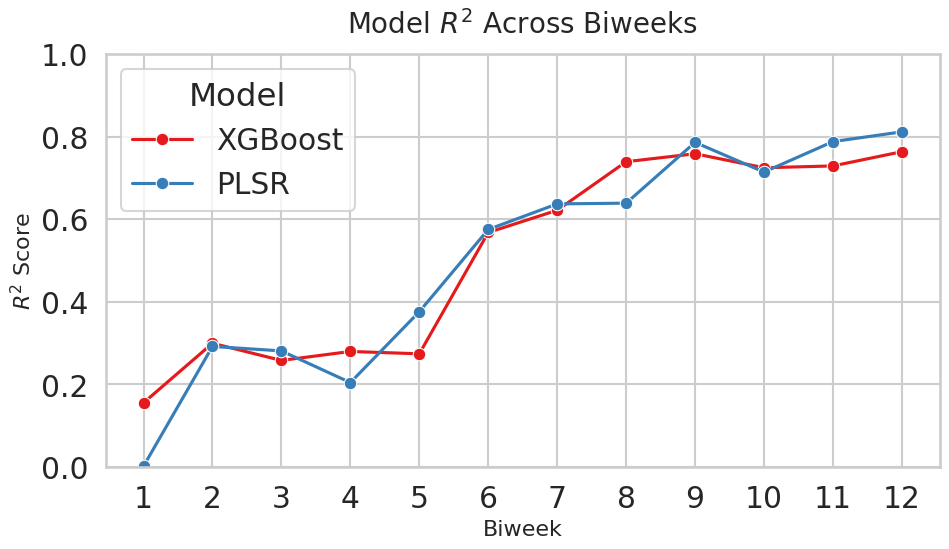

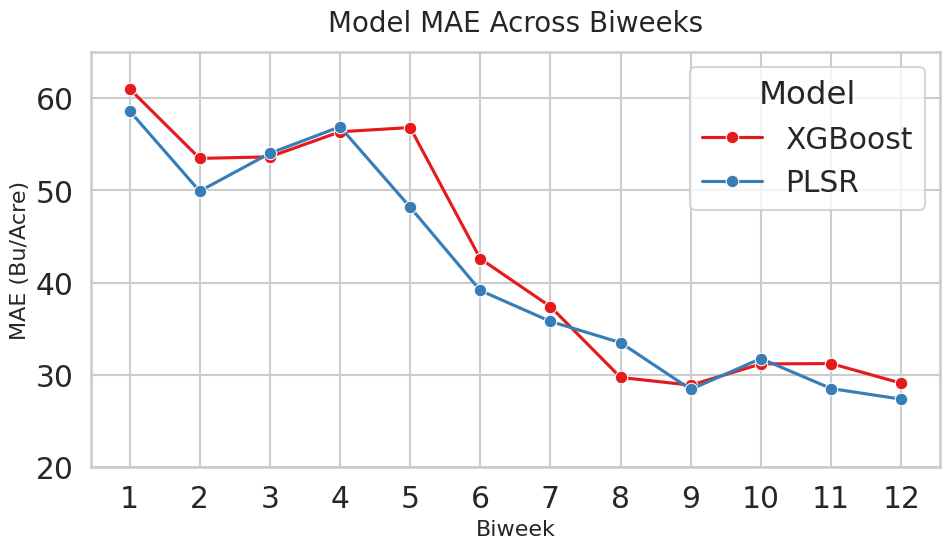

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_code = "s12wd"  # Specify the code used in filenames
# Set seaborn style for publication
sns.set(style="whitegrid", context="talk", font_scale=1.3)

# Load results
df = pd.read_csv(f"classical_ml_results_{_code}.csv")
df["biweek_num"] = df["biweek"].str.extract(r"(\d+)").astype(int)
df['test_mae'] = df['test_mae'] * 370
# Prepare R² data
r2_long = df.melt(
    id_vars=["biweek_num", "model"],
    value_vars=["test_r2"],
    var_name="split",
    value_name="R²"
)
r2_long["split"] = r2_long["split"].str.replace("_r2", "").str.capitalize()

# Plot R²
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=r2_long,
    x="biweek_num",
    y="R²",
    hue="model",
    marker="o",
    palette="Set1"
)
plt.title("Model $R^2$ Across Biweeks", fontsize=20, pad=15)
plt.ylim(0.0, 1.0)
plt.xlabel("Biweek", fontsize=16)
plt.ylabel("$R^2$ Score", fontsize=16)
plt.xticks(df["biweek_num"].unique())
plt.legend(title="Model", loc="best")
plt.tight_layout()
plt.savefig("classical_ml_r2_biweek.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Prepare MAE data
mae_long = df.melt(
    id_vars=["biweek_num", "model"],
    value_vars=["test_mae"],
    var_name="split",
    value_name="MAE"
)
mae_long["split"] = mae_long["split"].str.replace("_mae", "").str.capitalize()

# Plot MAE
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mae_long,
    x="biweek_num",
    y="MAE",
    hue="model",
    marker="o",
    palette="Set1"
)
plt.title("Model MAE Across Biweeks", fontsize=20, pad=15)
plt.xlabel("Biweek", fontsize=16)
plt.ylabel("MAE (Bu/Acre)", fontsize=16)
plt.xticks(df["biweek_num"].unique())
plt.ylim(20, 65)
plt.legend(title="Model", loc="best")
plt.tight_layout()
plt.savefig("classical_ml_mae_biweek.pdf", bbox_inches="tight", dpi=300)
plt.show()